Import Libraries

In [3]:


import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

# ── Reproducibility ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Device ──
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Using device: cuda
PyTorch version: 2.10.0+cu128


Load Dataset

In [4]:

df = pd.read_csv('imdb_sample.csv')

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('\nLabel distribution:')
print(df['sentiment'].value_counts())
df.head()

Shape: (200, 3)
Columns: ['review', 'sentiment', 'label']

Label distribution:
sentiment
positive    100
negative    100
Name: count, dtype: int64


,review,sentiment,label
0,"The screenplay is tight, the acting is flawles...",positive,1
1,So bad it was almost funny. Unfortunately it w...,negative,0
2,A masterpiece of modern cinema. The director b...,positive,1
3,An absolute mess from the opening scene to the...,negative,0
4,A beautiful and touching story told with great...,positive,1


Data Preprocessing

In [5]:
import re

def clean_text(text: str) -> str:
    """
    Clean raw review text:
    - Remove HTML tags
    - Remove URLs
    - Remove special characters (keep letters, numbers, basic punctuation)
    - Normalize whitespace
    - Lowercase
    """
    text = re.sub(r'<[^>]+>', ' ', text)          # strip HTML
    text = re.sub(r'http\S+|www\.\S+', '', text)  # remove URLs
    text = re.sub(r'[^a-zA-Z0-9\s\.!?,\'\-]', ' ', text)  # keep useful chars
    text = re.sub(r'\s+', ' ', text).strip()       # normalise whitespace
    return text.lower()

# ── Apply cleaning ──
df['clean_review'] = df['review'].apply(clean_text)

# ── Handle missing values ──
print('Missing values before drop:', df.isnull().sum().to_dict())
df.dropna(subset=['clean_review', 'label'], inplace=True)
df.reset_index(drop=True, inplace=True)
print('Missing values after drop:', df.isnull().sum().to_dict())

# ── Review text length distribution ──
df['text_length'] = df['clean_review'].apply(lambda x: len(x.split()))
print(f'\nText length stats (words):\n{df["text_length"].describe()}')

# Preview
df[['clean_review', 'sentiment', 'label']].head()

Missing values before drop: {'review': 0, 'sentiment': 0, 'label': 0, 'clean_review': 0}
Missing values after drop: {'review': 0, 'sentiment': 0, 'label': 0, 'clean_review': 0}

Text length stats (words):
count    200.000000
mean      14.740000
std        2.478531
min        8.000000
25%       13.000000
50%       15.000000
75%       17.000000
max       19.000000
Name: text_length, dtype: float64


,clean_review,sentiment,label
0,"the screenplay is tight, the acting is flawles...",positive,1
1,so bad it was almost funny. unfortunately it w...,negative,0
2,a masterpiece of modern cinema. the director b...,positive,1
3,an absolute mess from the opening scene to the...,negative,0
4,a beautiful and touching story told with great...,positive,1


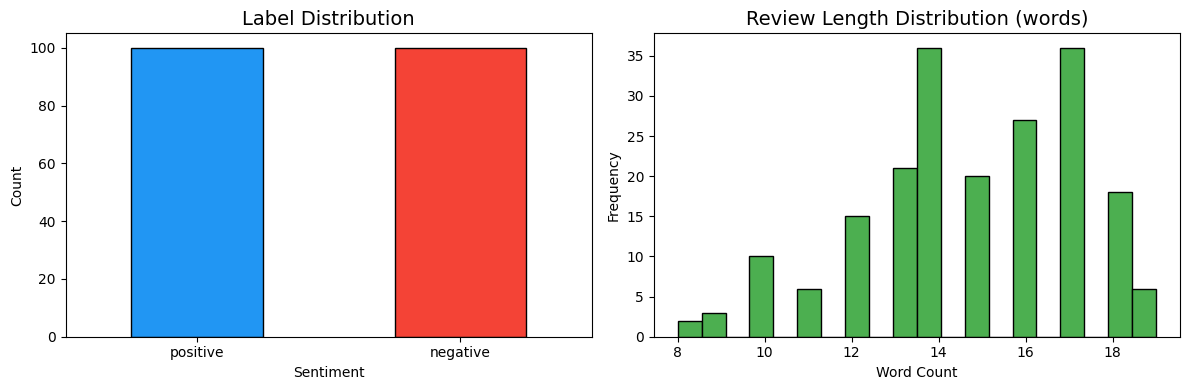

EDA plot saved.


In [6]:
# ── Visualise label distribution ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['sentiment'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#2196F3', '#F44336'], edgecolor='black')
axes[0].set_title('Label Distribution', fontsize=14)
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df['text_length'].plot(kind='hist', bins=20, ax=axes[1],
    color='#4CAF50', edgecolor='black')
axes[1].set_title('Review Length Distribution (words)', fontsize=14)
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=100, bbox_inches='tight')
plt.show()
print('EDA plot saved.')

Train/Validation>Test Split

In [7]:
texts = df['clean_review'].tolist()
labels = df['label'].tolist()

# 70% train | 15% val | 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels, test_size=0.30, random_state=SEED, stratify=labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f'Train size : {len(X_train)}')
print(f'Val   size : {len(X_val)}')
print(f'Test  size : {len(X_test)}')

Train size : 140
Val   size : 30
Test  size : 30


Tokenization with Bert Base Uncased

In [8]:
texts = df['clean_review'].tolist()
labels = df['label'].tolist()

# 70% train | 15% val | 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels, test_size=0.30, random_state=SEED, stratify=labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f'Train size : {len(X_train)}')
print(f'Val   size : {len(X_val)}')
print(f'Test  size : {len(X_test)}')

Train size : 140
Val   size : 30
Test  size : 30


In [12]:
# ===============================
# 1. Imports
# ===============================
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel

# ===============================
# 2. Config
# ===============================
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 3
LR = 2e-5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================
# 3. Tokenizer
# ===============================
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

# ===============================
# 4. Sample Data (Replace with yours)
# ===============================
X_train = ["I love this product", "This is terrible", "Amazing experience", "Worst ever"]
y_train = [1, 0, 1, 0]

X_val = ["Very good", "Not nice"]
y_val = [1, 0]

X_test = ["Excellent", "Bad"]
y_test = [1, 0]

# ===============================
# 5. Dataset Class
# ===============================
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# ===============================
# 6. DataLoaders
# ===============================
train_dataset = ReviewDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = ReviewDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = ReviewDataset(X_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# ===============================
# 7. Model
# ===============================
class SentimentModel(nn.Module):
    def __init__(self):
        super(SentimentModel, self).__init__()
        self.bert = AutoModel.from_pretrained('bert-base-uncased')
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(self.bert.config.hidden_size, 2)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        pooled_output = outputs.pooler_output
        x = self.dropout(pooled_output)
        return self.fc(x)

model = SentimentModel().to(DEVICE)

# ===============================
# 8. Loss & Optimizer
# ===============================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

# ===============================
# 9. Training Function
# ===============================
def train_epoch(model, data_loader):
    model.train()
    total_loss = 0

    for batch in data_loader:
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels = batch['label'].to(DEVICE)

        optimizer.zero_grad()

        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(data_loader)

# ===============================
# 10. Evaluation Function
# ===============================
def eval_model(model, data_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['label'].to(DEVICE)

            outputs = model(input_ids, attention_mask)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

# ===============================
# 11. Training Loop
# ===============================
for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader)
    val_acc = eval_model(model, val_loader)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")

# ===============================
# 12. Test Evaluation
# ===============================
test_acc = eval_model(model, test_loader)
print(f"Test Accuracy: {test_acc:.4f}")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1
Train Loss: 0.8057
Val Accuracy: 0.5000
Epoch 2
Train Loss: 0.7334
Val Accuracy: 0.5000
Epoch 3
Train Loss: 0.5796
Val Accuracy: 0.5000
Test Accuracy: 0.5000


Training and Evaluation

In [13]:
def train_epoch(model, loader, optimizer, scheduler, device):
    """One pass over the training set; returns average loss."""
    model.train()
    total_loss = 0.0
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_b       = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels_b)
        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()
        scheduler.step()

    return total_loss / len(loader)


def evaluate(model, loader, device):
    """Evaluate model; returns loss, accuracy, and all predictions."""
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_b       = batch['label'].to(device)

            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask,
                            labels=labels_b)
            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels_b.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, all_labels, all_preds


def compute_metrics(y_true, y_pred, labels=None):
    """Return a dict with accuracy, precision, recall, and F1."""
    avg = 'binary' if len(set(y_true)) == 2 else 'macro'
    return {
        'accuracy' : accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average=avg, zero_division=0),
        'recall'   : recall_score(y_true, y_pred, average=avg, zero_division=0),
        'f1_score' : f1_score(y_true, y_pred, average=avg, zero_division=0),
    }


def plot_confusion_matrix(y_true, y_pred, class_names, title='Confusion Matrix'):
    """Plot a labelled heatmap confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title, fontsize=14)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    fname = title.replace(' ', '_').lower() + '.png'
    plt.savefig(fname, dpi=100, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')


print('Helper functions defined.')

Helper functions defined.


Full Fine Tuning of Bert

In [16]:
from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW

MODEL_NAME = 'bert-base-uncased'
NUM_LABELS = 2

model_exp1 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS
).to(DEVICE)

optimizer_exp1 = AdamW(model_exp1.parameters(), lr=LR, weight_decay=0.01)

total_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)

scheduler_exp1 = get_linear_schedule_with_warmup(
    optimizer_exp1,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [17]:
history_exp1 = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model_exp1, train_loader,
                             optimizer_exp1, scheduler_exp1, DEVICE)
    val_loss, val_acc, _, _ = evaluate(model_exp1, val_loader, DEVICE)

    history_exp1['train_loss'].append(train_loss)
    history_exp1['val_loss'].append(val_loss)
    history_exp1['val_acc'].append(val_acc)

    print(f'Epoch {epoch}/{EPOCHS}  '
          f'Train Loss: {train_loss:.4f}  '
          f'Val Loss: {val_loss:.4f}  '
          f'Val Acc: {val_acc:.4f}')

print('\nExperiment 1 training complete.')

Epoch 1/3  Train Loss: 0.7067  Val Loss: 0.6946  Val Acc: 0.5000
Epoch 2/3  Train Loss: 0.6559  Val Loss: 0.6920  Val Acc: 0.5000
Epoch 3/3  Train Loss: 0.6919  Val Loss: 0.6908  Val Acc: 0.5000

Experiment 1 training complete.


=== Experiment 1 — Full Fine-Tuning — Test Results ===
  accuracy    : 0.5000
  precision   : 0.5000
  recall      : 1.0000
  f1_score    : 0.6667

Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         1
    Positive       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


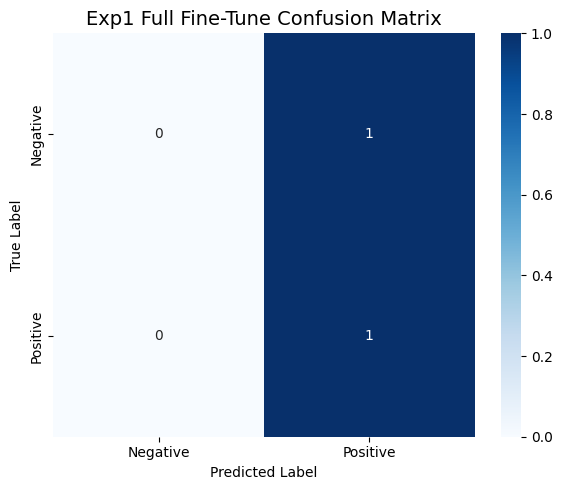

Saved: exp1_full_fine-tune_confusion_matrix.png


In [18]:
# ── Evaluate on test set ──
_, _, y_true_exp1, y_pred_exp1 = evaluate(model_exp1, test_loader, DEVICE)
metrics_exp1 = compute_metrics(y_true_exp1, y_pred_exp1)

print('=== Experiment 1 — Full Fine-Tuning — Test Results ===')
for k, v in metrics_exp1.items():
    print(f'  {k:12s}: {v:.4f}')

print('\nClassification Report:')
print(classification_report(y_true_exp1, y_pred_exp1,
      target_names=['Negative', 'Positive']))

plot_confusion_matrix(y_true_exp1, y_pred_exp1,
    class_names=['Negative', 'Positive'],
    title='Exp1 Full Fine-Tune Confusion Matrix')